In [1]:
!pip -q install -U tensorflow tensorflow-federated


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


Saving Huntington Disease Dataset.zip to Huntington Disease Dataset (5).zip
dataset shape: (48536, 21)
                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Los

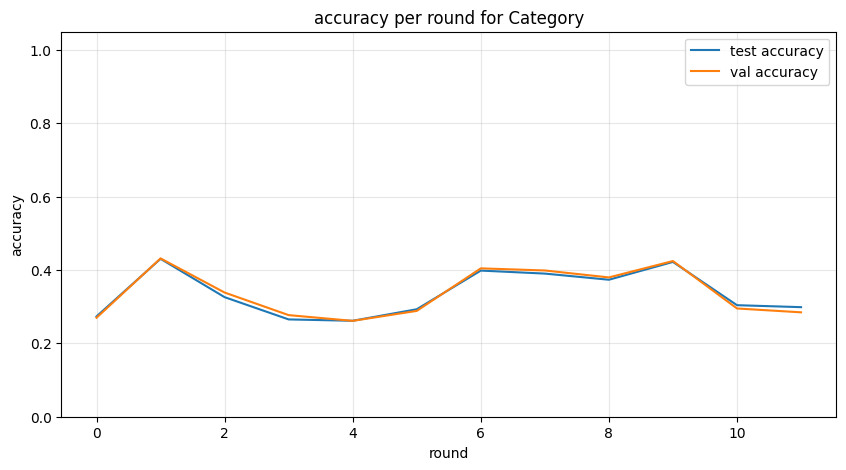


final test metrics for Category
accuracy: 0.2988
precision: 0.3767
recall: 0.2988
f1: 0.2917

final val metrics for Category
accuracy: 0.2847
precision: 0.3602
recall: 0.2847
f1: 0.2781


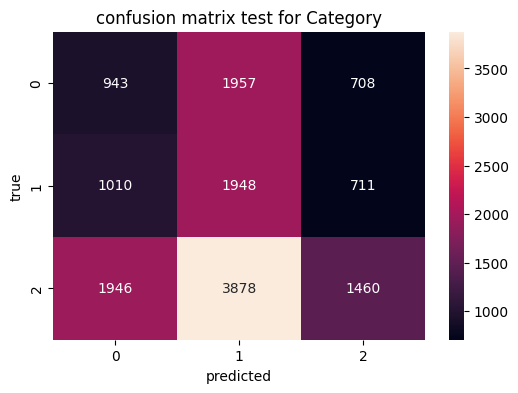

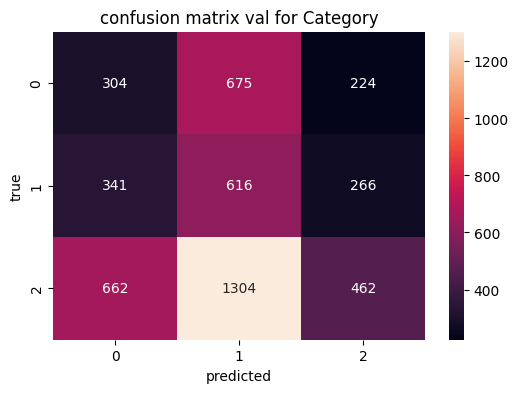


starting DP FedAvg for target: Motor_Symptoms
train size: 29121
test size: 14561
val size: 4854
features: 11
classes: 3
round: 1 test acc: 0.3343 val acc: 0.3267
round: 3 test acc: 0.3261 val acc: 0.3399
round: 6 test acc: 0.3306 val acc: 0.3294
round: 9 test acc: 0.3417 val acc: 0.3422
round: 12 test acc: 0.3332 val acc: 0.3389


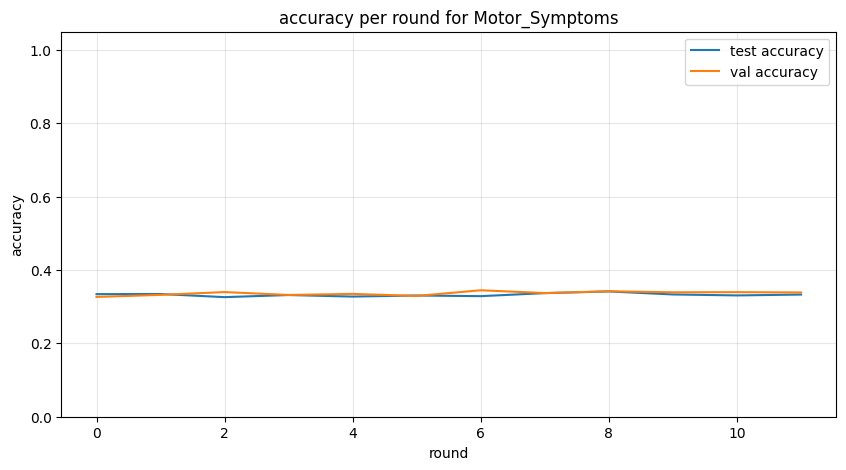


final test metrics for Motor_Symptoms
accuracy: 0.3332
precision: 0.338
recall: 0.3332
f1: 0.3173

final val metrics for Motor_Symptoms
accuracy: 0.3389
precision: 0.3367
recall: 0.3389
f1: 0.3187


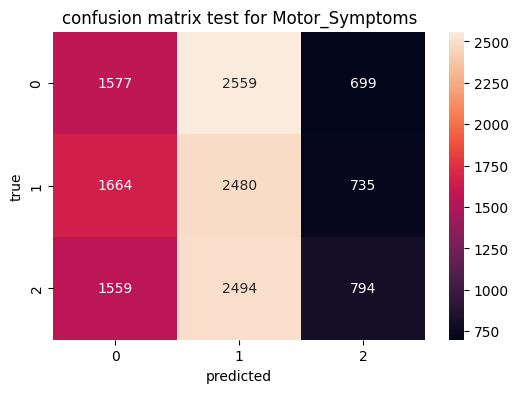

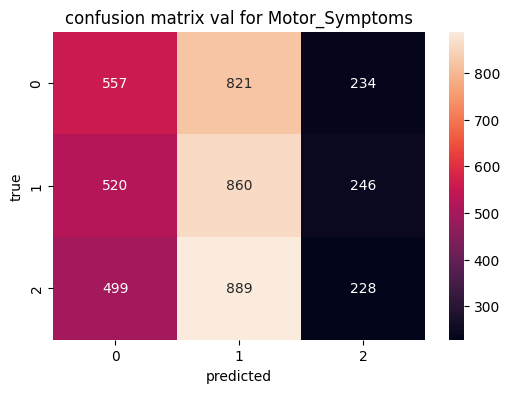


starting DP FedAvg for target: Disease_Stage
train size: 29121
test size: 14561
val size: 4854
features: 11
classes: 4
round: 1 test acc: 0.2472 val acc: 0.2509
round: 3 test acc: 0.2454 val acc: 0.2664
round: 6 test acc: 0.2463 val acc: 0.2513
round: 9 test acc: 0.2485 val acc: 0.2489
round: 12 test acc: 0.2526 val acc: 0.2406


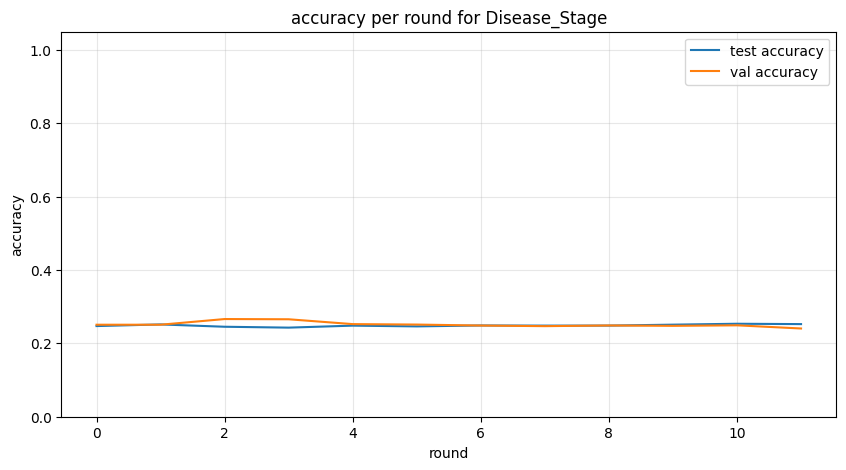


final test metrics for Disease_Stage
accuracy: 0.2526
precision: 0.2507
recall: 0.2526
f1: 0.2354

final val metrics for Disease_Stage
accuracy: 0.2406
precision: 0.2384
recall: 0.2406
f1: 0.2239


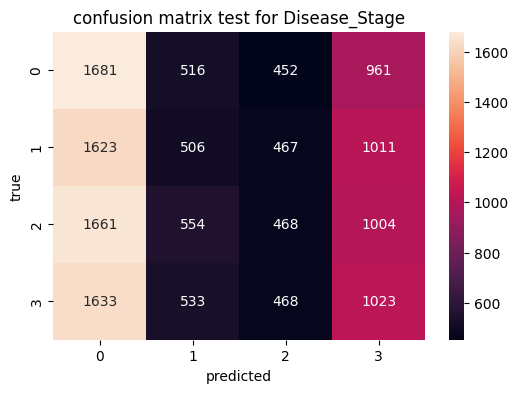

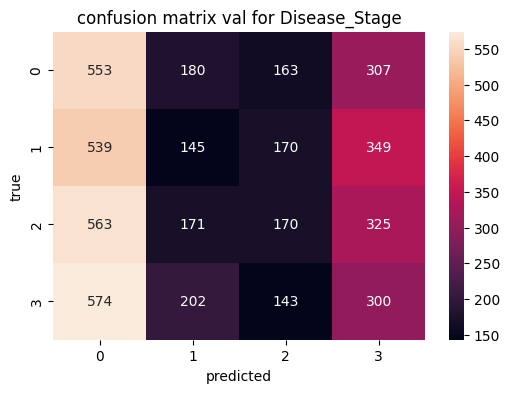


comparison table
           target  test_size  val_size  test_accuracy  test_precision  \
0        Category      14561      4854       0.298812        0.376677   
1  Motor_Symptoms      14561      4854       0.333150        0.338033   
2   Disease_Stage      14561      4854       0.252593        0.250728   

   test_recall   test_f1  val_accuracy  val_precision  val_recall    val_f1  
0     0.298812  0.291701      0.284714       0.360202    0.284714  0.278079  
1     0.333150  0.317311      0.338896       0.336679    0.338896  0.318684  
2     0.252593  0.235394      0.240626       0.238415    0.240626  0.223860  


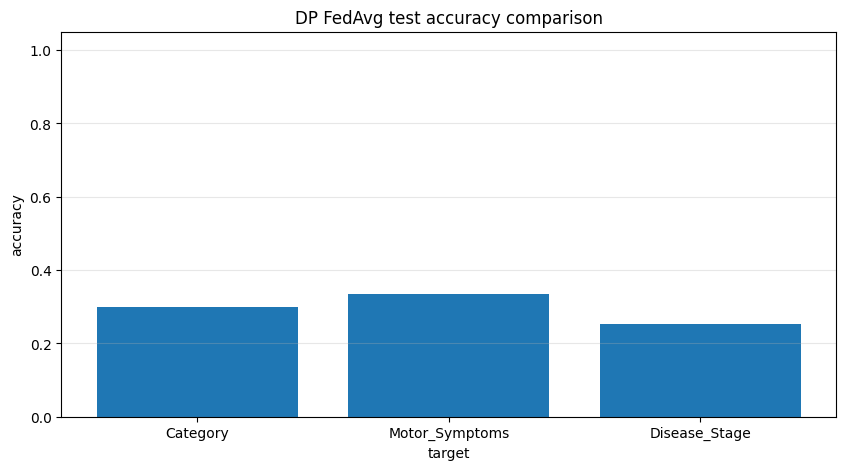

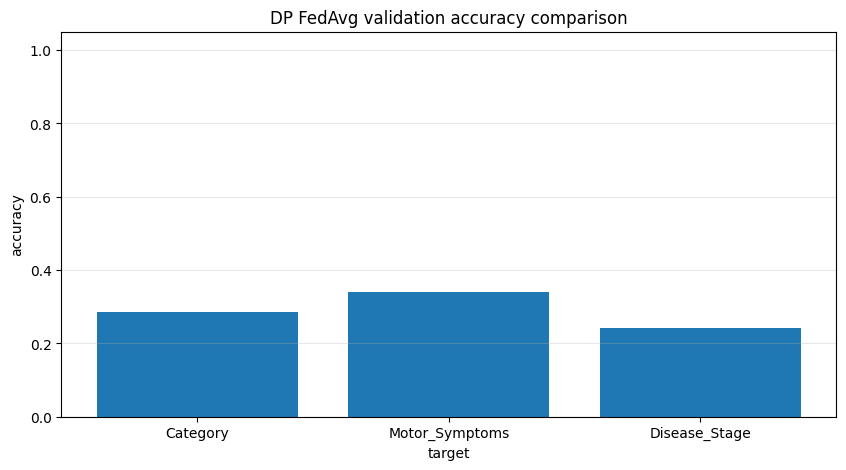


DP FedAvg was applied to these targets:
['Category', 'Motor_Symptoms', 'Disease_Stage']

overall test accuracy mean across targets: 0.2949
overall validation accuracy mean across targets: 0.2881

weighted overall test accuracy: 0.2949
weighted overall validation accuracy: 0.2881


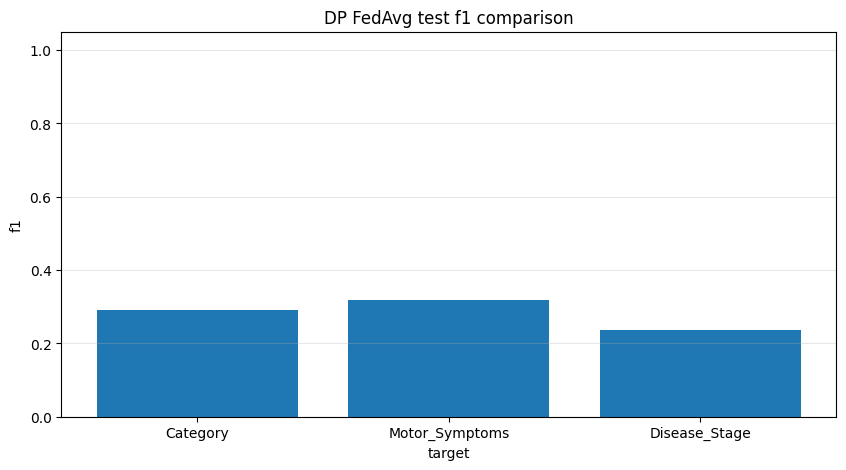

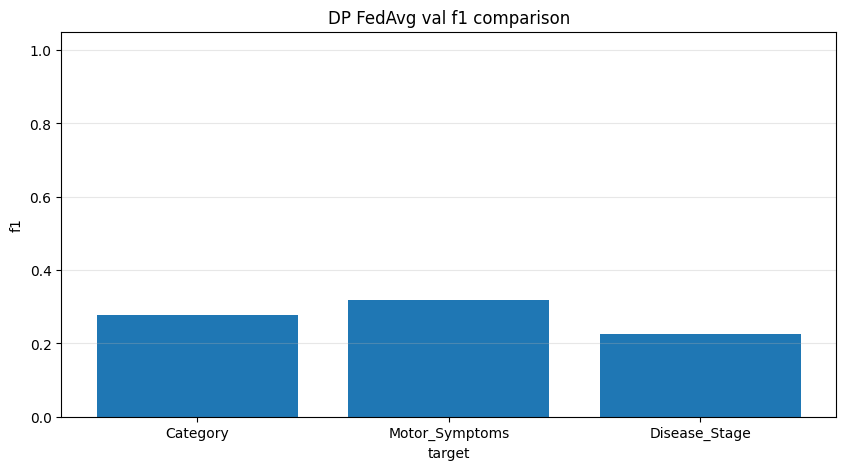

In [9]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, "r") as z:
    z.extractall("/content/")

csv_files = [f for f in os.listdir("/content/") if f.endswith(".csv")]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

csv_path = os.path.join("/content/", csv_files[0])
df = pd.read_csv(csv_path)

print("dataset shape:", df.shape)
print(df.head())

df = df.ffill()

df = df.drop(columns=[
    "Patient_ID",
    "Function",
    "Effect",
    "Gene/Factor",
    "Chromosome_Location",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence"
], errors="ignore")

label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

def build_model(num_features, num_classes):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(num_features,)))
    model.add(tf.keras.layers.Dense(64, activation="relu"))
    model.add(tf.keras.layers.Dense(32, activation="relu"))
    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model

def make_dataset(X_np, y_np, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X_np, y_np))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(5000, len(X_np)), seed=42)
    ds = ds.batch(batch_size)
    return ds

def split_into_clients(X_np, y_np, num_clients=5):
    idx = np.arange(len(X_np))
    np.random.seed(42)
    np.random.shuffle(idx)
    shards = np.array_split(idx, num_clients)
    clients = []
    for s in shards:
        clients.append((X_np[s], y_np[s]))
    return clients

def get_weights(model):
    return [w.copy() for w in model.get_weights()]

def set_weights(model, weights):
    model.set_weights(weights)

def subtract_weights(a, b):
    return [ai - bi for ai, bi in zip(a, b)]

def add_weights(a, b):
    return [ai + bi for ai, bi in zip(a, b)]

def scale_weights(weights, scalar):
    return [w * scalar for w in weights]

def l2_norm(weights):
    return np.sqrt(sum(np.sum(w * w) for w in weights))

def clip_update(update, clip_norm):
    n = l2_norm(update)
    if n == 0:
        return update
    factor = min(1.0, clip_norm / n)
    return scale_weights(update, factor)

def add_gaussian_noise(update, noise_std):
    noisy = []
    for w in update:
        noisy.append(w + np.random.normal(loc=0.0, scale=noise_std, size=w.shape).astype(w.dtype))
    return noisy

def predict_classes(model, X_np, batch_size=512):
    probs = model.predict(X_np, batch_size=batch_size, verbose=0)
    return np.argmax(probs, axis=1)

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.show()

def plot_accuracy_curve(history_test, history_val, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history_test, label="test accuracy")
    plt.plot(history_val, label="val accuracy")
    plt.title(title)
    plt.xlabel("round")
    plt.ylabel("accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def run_dp_fedavg_for_target(target_name):
    print("\nstarting DP FedAvg for target:", target_name)

    if target_name not in df.columns:
        print("target not found:", target_name)
        return None

    y = df[target_name].astype(int)
    X = df.drop(columns=["Motor_Symptoms", "Disease_Stage", "Category"], errors="ignore")

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.40,
        random_state=42,
        stratify=y if y.nunique() > 1 else None
    )

    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp,
        test_size=0.25,
        random_state=42,
        stratify=y_temp if y_temp.nunique() > 1 else None
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)

    y_train = y_train.to_numpy().astype(np.int32)
    y_test = y_test.to_numpy().astype(np.int32)
    y_val = y_val.to_numpy().astype(np.int32)

    num_features = X_train.shape[1]
    num_classes = int(np.max(y_train)) + 1

    print("train size:", len(X_train))
    print("test size:", len(X_test))
    print("val size:", len(X_val))
    print("features:", num_features)
    print("classes:", num_classes)

    NUM_CLIENTS = 5
    CLIENT_EPOCHS = 1
    BATCH_SIZE = 32
    ROUNDS = 12

    CLIP_NORM = 1.0
    NOISE_MULTIPLIER = 0.8
    NOISE_STD = NOISE_MULTIPLIER * CLIP_NORM

    clients = split_into_clients(X_train, y_train, num_clients=NUM_CLIENTS)

    global_model = build_model(num_features, num_classes)
    global_weights = get_weights(global_model)

    history_test_acc = []
    history_val_acc = []

    for r in range(1, ROUNDS + 1):
        client_updates = []
        client_sizes = []

        for (Xc, yc) in clients:
            local_model = build_model(num_features, num_classes)
            set_weights(local_model, global_weights)

            ds_client = make_dataset(Xc, yc, batch_size=BATCH_SIZE, shuffle=True)
            local_model.fit(ds_client, epochs=CLIENT_EPOCHS, verbose=0)

            new_weights = get_weights(local_model)
            update = subtract_weights(new_weights, global_weights)

            update = clip_update(update, CLIP_NORM)
            update = add_gaussian_noise(update, NOISE_STD)

            client_updates.append(update)
            client_sizes.append(len(Xc))

        total = float(sum(client_sizes))
        agg_update = None
        for update, sz in zip(client_updates, client_sizes):
            weighted = scale_weights(update, sz / total)
            agg_update = weighted if agg_update is None else add_weights(agg_update, weighted)

        global_weights = add_weights(global_weights, agg_update)
        set_weights(global_model, global_weights)

        y_pred_test = predict_classes(global_model, X_test)
        y_pred_val = predict_classes(global_model, X_val)

        test_acc = accuracy_score(y_test, y_pred_test)
        val_acc = accuracy_score(y_val, y_pred_val)

        history_test_acc.append(test_acc)
        history_val_acc.append(val_acc)

        if r == 1 or r % 3 == 0:
            print("round:", r, "test acc:", round(test_acc, 4), "val acc:", round(val_acc, 4))

    plot_accuracy_curve(history_test_acc, history_val_acc, "accuracy per round for " + target_name)

    y_pred_test = predict_classes(global_model, X_test)
    y_pred_val = predict_classes(global_model, X_val)

    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
    test_rec = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
    test_f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

    val_acc = accuracy_score(y_val, y_pred_val)
    val_prec = precision_score(y_val, y_pred_val, average="weighted", zero_division=0)
    val_rec = recall_score(y_val, y_pred_val, average="weighted", zero_division=0)
    val_f1 = f1_score(y_val, y_pred_val, average="weighted", zero_division=0)

    print("\nfinal test metrics for", target_name)
    print("accuracy:", round(test_acc, 4))
    print("precision:", round(test_prec, 4))
    print("recall:", round(test_rec, 4))
    print("f1:", round(test_f1, 4))

    print("\nfinal val metrics for", target_name)
    print("accuracy:", round(val_acc, 4))
    print("precision:", round(val_prec, 4))
    print("recall:", round(val_rec, 4))
    print("f1:", round(val_f1, 4))

    plot_confusion(y_test, y_pred_test, "confusion matrix test for " + target_name)
    plot_confusion(y_val, y_pred_val, "confusion matrix val for " + target_name)

    return {
        "target": target_name,
        "test_size": int(len(y_test)),
        "val_size": int(len(y_val)),
        "test_accuracy": test_acc,
        "test_precision": test_prec,
        "test_recall": test_rec,
        "test_f1": test_f1,
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1
    }

targets = ["Category", "Motor_Symptoms", "Disease_Stage"]
all_results = []

for t in targets:
    res = run_dp_fedavg_for_target(t)
    if res is not None:
        all_results.append(res)

results_df = pd.DataFrame(all_results)
print("\ncomparison table")
print(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["target"], results_df["test_accuracy"])
plt.title("DP FedAvg test accuracy comparison")
plt.xlabel("target")
plt.ylabel("accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["target"], results_df["val_accuracy"])
plt.title("DP FedAvg validation accuracy comparison")
plt.xlabel("target")
plt.ylabel("accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\nDP FedAvg was applied to these targets:")
print(results_df["target"].tolist())

overall_test_acc_mean = results_df["test_accuracy"].mean()
overall_val_acc_mean = results_df["val_accuracy"].mean()

weighted_test_acc = np.average(results_df["test_accuracy"], weights=results_df["test_size"])
weighted_val_acc = np.average(results_df["val_accuracy"], weights=results_df["val_size"])

print("\noverall test accuracy mean across targets:", round(float(overall_test_acc_mean), 4))
print("overall validation accuracy mean across targets:", round(float(overall_val_acc_mean), 4))

print("\nweighted overall test accuracy:", round(float(weighted_test_acc), 4))
print("weighted overall validation accuracy:", round(float(weighted_val_acc), 4))

plt.figure(figsize=(10, 5))
plt.bar(results_df["target"], results_df["test_f1"])
plt.title("DP FedAvg test f1 comparison")
plt.xlabel("target")
plt.ylabel("f1")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["target"], results_df["val_f1"])
plt.title("DP FedAvg val f1 comparison")
plt.xlabel("target")
plt.ylabel("f1")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()
